In [1]:
from pathlib import Path

import json
import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path(
    r"C:\Users\delll\Desktop\SmartRoute"
)

baseline_metrics_path = (
    PROJECT_ROOT
    / "outputs/reports/baseline_metrics.json"
)

transformer_metrics_path = (
    PROJECT_ROOT
    / "outputs/reports/transformer_metrics.json"
)

with open(
    baseline_metrics_path,
    encoding="utf-8"
) as file:
    baseline_metrics = json.load(file)

with open(
    transformer_metrics_path,
    encoding="utf-8"
) as file:
    transformer_metrics = json.load(file)

comparison_df = pd.DataFrame([
    {
        "Model": "TF-IDF + Logistic Regression",
        "Accuracy": baseline_metrics["accuracy"],
        "Precision": baseline_metrics["weighted_precision"],
        "Recall": baseline_metrics["weighted_recall"],
        "F1-score": baseline_metrics["weighted_f1"],
        "Latency (ms)": baseline_metrics["average_latency_ms"]
    },
    {
        "Model": "Multilingual DistilBERT",
        "Accuracy": transformer_metrics["accuracy"],
        "Precision": transformer_metrics["weighted_precision"],
        "Recall": transformer_metrics["weighted_recall"],
        "F1-score": transformer_metrics["weighted_f1"],
        "Latency (ms)": transformer_metrics["model_latency_ms"]
    }
])

comparison_df.round(4)

,Model,Accuracy,Precision,Recall,F1-score,Latency (ms)
0,TF-IDF + Logistic Regression,0.8278,0.8514,0.8278,0.8305,0.4291
1,Multilingual DistilBERT,0.7181,0.7874,0.7181,0.7271,20.6441


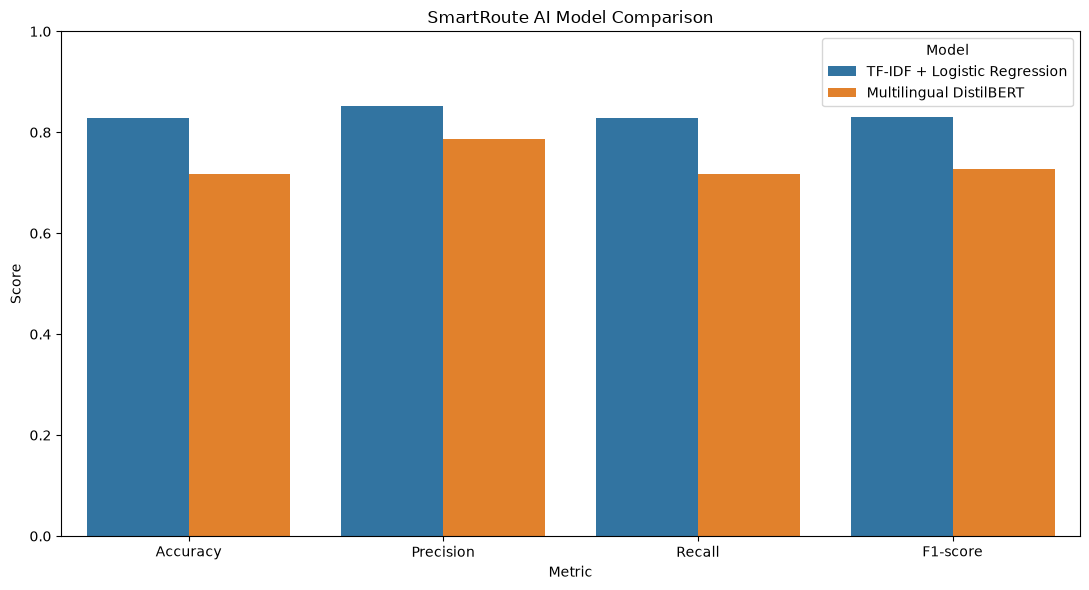

Chart saved: C:\Users\delll\Desktop\SmartRoute\outputs\figures\model_comparison.png


In [2]:
plot_df = comparison_df.melt(
    id_vars="Model",
    value_vars=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=plot_df,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.ylim(0, 1)
plt.title("SmartRoute AI Model Comparison")
plt.ylabel("Score")
plt.tight_layout()

comparison_chart_path = (
    PROJECT_ROOT
    / "outputs/figures/model_comparison.png"
)

plt.savefig(
    comparison_chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved:", comparison_chart_path)

In [3]:
comparison_path = (
    PROJECT_ROOT
    / "outputs/reports/model_comparison.csv"
)

comparison_df.to_csv(comparison_path, index=False)

print("✅ Model comparison saved!")

✅ Model comparison saved!


In [6]:
import re
import time

model_path = (
    PROJECT_ROOT
    / "models/baseline/tfidf_logistic_regression.joblib"
)

selected_model = joblib.load(model_path)

DEPARTMENT_MAP = {
    "Payment Issue": "Payments Team",
    "Delivery Issue": "Logistics Team",
    "Refund Issue": "Refund Team",
    "Cancellation Issue": "Order Management",
    "Product Issue": "Product Support",
    "Return/Replacement": "Returns Team",
    "Account Issue": "Account Support",
    "Fraud/Security": "Security Team"
}

HINGLISH_MARKERS = {
    "mera", "meri", "mere", "maine", "mujhe",
    "nahi", "abhi", "tak", "gaya", "gayi",
    "hua", "hui", "hai", "hoon", "paise",
    "karna", "karo", "chahiye", "kyunki"
}

CRITICAL_TERMS = [
    "fraud", "hacked", "hack", "unauthorised",
    "unauthorized", "unknown transaction",
    "without permission", "suspicious transaction",
    "अनजान लेन-देन", "हैक", "बिना अनुमति"
]

HIGH_TERMS = [
    "deducted", "debited", "charged twice",
    "refund", "damaged", "defective",
    "money deducted", "payment failed",
    "पैसे कट", "रिफंड", "खराब",
    "deduct", "debit", "refund nahi",
    "damaged product"
]

def detect_language(text):
    if re.search(r"[\u0900-\u097F]", text):
        return "Hindi"

    words = set(
        re.findall(r"[a-zA-Z]+", text.lower())
    )

    if words.intersection(HINGLISH_MARKERS):
        return "Hinglish"

    return "English"

def assign_priority(text, category):
    normalized_text = text.lower()

    if (
        category == "Fraud/Security"
        or any(
            term in normalized_text
            for term in CRITICAL_TERMS
        )
    ):
        return "Critical"

    if any(
        term in normalized_text
        for term in HIGH_TERMS
    ):
        return "High"

    if category in {
        "Payment Issue",
        "Refund Issue",
        "Product Issue"
    }:
        return "High"

    return "Medium"

def predict_complaint(text, review_threshold=0.60):
    if not isinstance(text, str) or not text.strip():
        raise ValueError("Complaint text cannot be empty.")

    clean_text = " ".join(text.strip().split())

    start_time = time.perf_counter()

    probabilities = selected_model.predict_proba(
        [clean_text]
    )[0]

    predicted_category = selected_model.classes_[
        probabilities.argmax()
    ]

    confidence = float(probabilities.max())

    processing_time_ms = (
        time.perf_counter() - start_time
    ) * 1000

    result = {
        "input_text": clean_text,
        "detected_language": detect_language(clean_text),
        "category": predicted_category,
        "department": DEPARTMENT_MAP[predicted_category],
        "priority": assign_priority(
            clean_text,
            predicted_category
        ),
        "confidence": round(confidence, 4),
        "processing_time_ms": round(
            processing_time_ms,
            2
        ),
        "requires_human_review": (
            confidence < review_threshold
        )
    }

    return result

In [7]:
test_complaints = [
    "My payment was deducted, but the order was not confirmed.",
    "मेरा ऑर्डर अभी तक नहीं आया है।",
    "Maine order cancel kiya but refund abhi tak nahi mila."
]

for complaint in test_complaints:
    result = predict_complaint(complaint)

    print(json.dumps(
        result,
        indent=4,
        ensure_ascii=False
    ))

    print("-" * 60)

{
    "input_text": "My payment was deducted, but the order was not confirmed.",
    "detected_language": "English",
    "category": "Payment Issue",
    "department": "Payments Team",
    "priority": "High",
    "confidence": 0.9654,
    "processing_time_ms": 3.65,
    "requires_human_review": false
}
------------------------------------------------------------
{
    "input_text": "मेरा ऑर्डर अभी तक नहीं आया है।",
    "detected_language": "Hindi",
    "category": "Delivery Issue",
    "department": "Logistics Team",
    "priority": "Medium",
    "confidence": 0.8971,
    "processing_time_ms": 2.37,
    "requires_human_review": false
}
------------------------------------------------------------
{
    "input_text": "Maine order cancel kiya but refund abhi tak nahi mila.",
    "detected_language": "Hinglish",
    "category": "Refund Issue",
    "department": "Refund Team",
    "priority": "High",
    "confidence": 0.9366,
    "processing_time_ms": 2.06,
    "requires_human_review": fals

In [8]:
test_complaints = [
    "My payment was deducted, but the order was not confirmed.",
    "मेरा ऑर्डर अभी तक नहीं आया है।",
    "Maine order cancel kiya but refund abhi tak nahi mila."
]

for complaint in test_complaints:
    result = predict_complaint(complaint)

    print(json.dumps(
        result,
        indent=4,
        ensure_ascii=False
    ))

    print("-" * 60)

{
    "input_text": "My payment was deducted, but the order was not confirmed.",
    "detected_language": "English",
    "category": "Payment Issue",
    "department": "Payments Team",
    "priority": "High",
    "confidence": 0.9654,
    "processing_time_ms": 3.96,
    "requires_human_review": false
}
------------------------------------------------------------
{
    "input_text": "मेरा ऑर्डर अभी तक नहीं आया है।",
    "detected_language": "Hindi",
    "category": "Delivery Issue",
    "department": "Logistics Team",
    "priority": "Medium",
    "confidence": 0.8971,
    "processing_time_ms": 4.93,
    "requires_human_review": false
}
------------------------------------------------------------
{
    "input_text": "Maine order cancel kiya but refund abhi tak nahi mila.",
    "detected_language": "Hinglish",
    "category": "Refund Issue",
    "department": "Refund Team",
    "priority": "High",
    "confidence": 0.9366,
    "processing_time_ms": 3.09,
    "requires_human_review": fals

In [9]:
%%writefile C:/Users/delll/Desktop/SmartRoute/backend/prediction_service.py

UsageError: %%writefile is a cell magic, but the cell body is empty.


In [12]:
%%writefile C:/Users/delll/Desktop/SmartRoute/backend/prediction_service.py
from pathlib import Path
import re
import time
import joblib

PROJECT_ROOT = Path(__file__).resolve().parent.parent
MODEL_PATH = PROJECT_ROOT / "models/baseline/tfidf_logistic_regression.joblib"

model = joblib.load(MODEL_PATH)

DEPARTMENT_MAP = {
    "Payment Issue": "Payments Team",
    "Delivery Issue": "Logistics Team",
    "Refund Issue": "Refund Team",
    "Cancellation Issue": "Order Management",
    "Product Issue": "Product Support",
    "Return/Replacement": "Returns Team",
    "Account Issue": "Account Support",
    "Fraud/Security": "Security Team"
}

HINGLISH_MARKERS = {
    "mera", "meri", "mere", "maine", "mujhe",
    "nahi", "abhi", "tak", "gaya", "gayi",
    "hua", "hui", "hai", "hoon", "paise",
    "karna", "karo", "chahiye", "kyunki"
}

CRITICAL_TERMS = [
    "fraud",
    "hacked",
    "hack",
    "unauthorised",
    "unauthorized",
    "unknown transaction",
    "without permission",
    "suspicious transaction",
    "अनजान लेन-देन",
    "हैक",
    "बिना अनुमति"
]

HIGH_TERMS = [
    "deducted",
    "debited",
    "charged twice",
    "refund",
    "damaged",
    "defective",
    "payment failed",
    "पैसे कट",
    "रिफंड",
    "खराब",
    "deduct",
    "debit"
]


def detect_language(text):
    if re.search(r"[\u0900-\u097F]", text):
        return "Hindi"

    words = set(re.findall(r"[a-zA-Z]+", text.lower()))

    if words.intersection(HINGLISH_MARKERS):
        return "Hinglish"

    return "English"


def assign_priority(text, category):
    normalized_text = text.lower()

    if category == "Fraud/Security":
        return "Critical"

    if any(term in normalized_text for term in CRITICAL_TERMS):
        return "Critical"

    if any(term in normalized_text for term in HIGH_TERMS):
        return "High"

    if category in {
        "Payment Issue",
        "Refund Issue",
        "Product Issue"
    }:
        return "High"

    return "Medium"


def predict_complaint(text, review_threshold=0.60):
    if not isinstance(text, str) or not text.strip():
        raise ValueError("Complaint text cannot be empty.")

    clean_text = " ".join(text.strip().split())
    start_time = time.perf_counter()

    probabilities = model.predict_proba([clean_text])[0]
    predicted_category = model.classes_[probabilities.argmax()]
    confidence = float(probabilities.max())

    processing_time_ms = (
        time.perf_counter() - start_time
    ) * 1000

    return {
        "input_text": clean_text,
        "detected_language": detect_language(clean_text),
        "category": predicted_category,
        "department": DEPARTMENT_MAP[predicted_category],
        "priority": assign_priority(clean_text, predicted_category),
        "confidence": round(confidence, 4),
        "processing_time_ms": round(processing_time_ms, 2),
        "requires_human_review": confidence < review_threshold
    }

Overwriting C:/Users/delll/Desktop/SmartRoute/backend/prediction_service.py


In [1]:
from backend.prediction_service import predict_complaint

predict_complaint(
    "Payment ho gaya but order place nahi hua"
)

{'input_text': 'Payment ho gaya but order place nahi hua',
 'detected_language': 'Hinglish',
 'category': 'Payment Issue',
 'department': 'Payments Team',
 'priority': 'High',
 'confidence': 0.9245,
 'processing_time_ms': 7.68,
 'requires_human_review': False}

In [2]:
%%writefile C:/Users/delll/Desktop/SmartRoute/backend/database.py
from datetime import datetime, timezone
from pathlib import Path
import sqlite3


PROJECT_ROOT = Path(__file__).resolve().parent.parent
DATABASE_PATH = PROJECT_ROOT / "data/smartroute.db"


def get_connection():
    DATABASE_PATH.parent.mkdir(parents=True, exist_ok=True)

    connection = sqlite3.connect(DATABASE_PATH)
    connection.row_factory = sqlite3.Row

    return connection


def initialize_database():
    with get_connection() as connection:
        connection.execute("""
            CREATE TABLE IF NOT EXISTS predictions (
                id INTEGER PRIMARY KEY AUTOINCREMENT,
                input_text TEXT NOT NULL,
                detected_language TEXT NOT NULL,
                category TEXT NOT NULL,
                department TEXT NOT NULL,
                priority TEXT NOT NULL,
                confidence REAL NOT NULL,
                processing_time_ms REAL NOT NULL,
                requires_human_review INTEGER NOT NULL,
                created_at TEXT NOT NULL
            )
        """)

        connection.execute("""
            CREATE TABLE IF NOT EXISTS feedback (
                id INTEGER PRIMARY KEY AUTOINCREMENT,
                prediction_id INTEGER NOT NULL,
                corrected_category TEXT NOT NULL,
                notes TEXT,
                created_at TEXT NOT NULL,
                FOREIGN KEY (prediction_id)
                    REFERENCES predictions(id)
            )
        """)


def save_prediction(result):
    created_at = datetime.now(timezone.utc).isoformat()

    with get_connection() as connection:
        cursor = connection.execute("""
            INSERT INTO predictions (
                input_text,
                detected_language,
                category,
                department,
                priority,
                confidence,
                processing_time_ms,
                requires_human_review,
                created_at
            )
            VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?)
        """, (
            result["input_text"],
            result["detected_language"],
            result["category"],
            result["department"],
            result["priority"],
            result["confidence"],
            result["processing_time_ms"],
            int(result["requires_human_review"]),
            created_at
        ))

        prediction_id = cursor.lastrowid

    return prediction_id, created_at


def get_predictions(limit=100):
    with get_connection() as connection:
        rows = connection.execute("""
            SELECT *
            FROM predictions
            ORDER BY id DESC
            LIMIT ?
        """, (limit,)).fetchall()

    results = []

    for row in rows:
        item = dict(row)
        item["requires_human_review"] = bool(
            item["requires_human_review"]
        )
        results.append(item)

    return results


def save_feedback(prediction_id, corrected_category, notes=None):
    created_at = datetime.now(timezone.utc).isoformat()

    with get_connection() as connection:
        prediction = connection.execute(
            "SELECT id FROM predictions WHERE id = ?",
            (prediction_id,)
        ).fetchone()

        if prediction is None:
            return None

        cursor = connection.execute("""
            INSERT INTO feedback (
                prediction_id,
                corrected_category,
                notes,
                created_at
            )
            VALUES (?, ?, ?, ?)
        """, (
            prediction_id,
            corrected_category,
            notes,
            created_at
        ))

        feedback_id = cursor.lastrowid

    return feedback_id, created_at


def get_metrics():
    with get_connection() as connection:
        prediction_metrics = connection.execute("""
            SELECT
                COUNT(*) AS total_complaints,
                AVG(confidence) AS average_confidence,
                AVG(processing_time_ms) AS average_latency_ms,
                SUM(requires_human_review) AS review_queue_size
            FROM predictions
        """).fetchone()

        feedback_count = connection.execute("""
            SELECT COUNT(*) AS feedback_count
            FROM feedback
        """).fetchone()

        category_rows = connection.execute("""
            SELECT category, COUNT(*) AS count
            FROM predictions
            GROUP BY category
            ORDER BY count DESC
        """).fetchall()

        language_rows = connection.execute("""
            SELECT detected_language, COUNT(*) AS count
            FROM predictions
            GROUP BY detected_language
            ORDER BY count DESC
        """).fetchall()

    metrics = dict(prediction_metrics)

    metrics["average_confidence"] = round(
        metrics["average_confidence"] or 0,
        4
    )

    metrics["average_latency_ms"] = round(
        metrics["average_latency_ms"] or 0,
        2
    )

    metrics["review_queue_size"] = (
        metrics["review_queue_size"] or 0
    )

    metrics["feedback_count"] = (
        feedback_count["feedback_count"]
    )

    metrics["category_distribution"] = {
        row["category"]: row["count"]
        for row in category_rows
    }

    metrics["language_distribution"] = {
        row["detected_language"]: row["count"]
        for row in language_rows
    }

    return metrics


def get_alerts(limit=50):
    with get_connection() as connection:
        rows = connection.execute("""
            SELECT *
            FROM predictions
            WHERE requires_human_review = 1
               OR priority = 'Critical'
            ORDER BY id DESC
            LIMIT ?
        """, (limit,)).fetchall()

    alerts = []

    for row in rows:
        item = dict(row)
        item["requires_human_review"] = bool(
            item["requires_human_review"]
        )
        alerts.append(item)

    return alerts

Writing C:/Users/delll/Desktop/SmartRoute/backend/database.py


In [3]:
from backend.database import (
    DATABASE_PATH,
    get_metrics,
    initialize_database
)

initialize_database()

print("Database created:", DATABASE_PATH.exists())
print("Database location:", DATABASE_PATH)
print(get_metrics())

Database created: True
Database location: C:\Users\delll\Desktop\SmartRoute\data\smartroute.db
{'total_complaints': 0, 'average_confidence': 0, 'average_latency_ms': 0, 'review_queue_size': 0, 'feedback_count': 0, 'category_distribution': {}, 'language_distribution': {}}


In [4]:
%%writefile C:/Users/delll/Desktop/SmartRoute/backend/app.py
from contextlib import asynccontextmanager

from fastapi import FastAPI, HTTPException, Query
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel, Field

from backend.database import (
    get_alerts,
    get_metrics,
    get_predictions,
    initialize_database,
    save_feedback,
    save_prediction
)
from backend.prediction_service import (
    DEPARTMENT_MAP,
    predict_complaint
)


@asynccontextmanager
async def lifespan(app: FastAPI):
    initialize_database()
    yield


app = FastAPI(
    title="SmartRoute AI API",
    description=(
        "Live multilingual e-commerce grievance "
        "classification and routing API"
    ),
    version="1.0.0",
    lifespan=lifespan
)


app.add_middleware(
    CORSMiddleware,
    allow_origins=[
        "http://localhost:3000",
        "http://127.0.0.1:3000",
        "http://localhost:5173",
        "http://127.0.0.1:5173"
    ],
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"]
)


class PredictionRequest(BaseModel):
    text: str = Field(
        min_length=3,
        max_length=2000,
        examples=[
            "Payment ho gaya but order place nahi hua"
        ]
    )


class FeedbackRequest(BaseModel):
    prediction_id: int = Field(gt=0)
    corrected_category: str
    notes: str | None = Field(
        default=None,
        max_length=1000
    )


@app.get("/")
def root():
    return {
        "name": "SmartRoute AI",
        "status": "running",
        "version": "1.0.0",
        "documentation": "/docs"
    }


@app.get("/health")
def health():
    return {
        "status": "healthy",
        "model": "TF-IDF + Logistic Regression",
        "supported_languages": [
            "English",
            "Hindi",
            "Hinglish"
        ],
        "categories": list(DEPARTMENT_MAP.keys())
    }


@app.post("/predict")
def predict(request: PredictionRequest):
    try:
        result = predict_complaint(request.text)

        prediction_id, created_at = save_prediction(
            result
        )

        return {
            "prediction_id": prediction_id,
            **result,
            "created_at": created_at
        }

    except ValueError as error:
        raise HTTPException(
            status_code=400,
            detail=str(error)
        ) from error

    except Exception as error:
        raise HTTPException(
            status_code=500,
            detail="Prediction failed."
        ) from error


@app.get("/predictions")
def predictions(
    limit: int = Query(
        default=100,
        ge=1,
        le=500
    )
):
    return {
        "count": limit,
        "predictions": get_predictions(limit)
    }


@app.get("/metrics")
def metrics():
    return get_metrics()


@app.post("/feedback")
def feedback(request: FeedbackRequest):
    if request.corrected_category not in DEPARTMENT_MAP:
        raise HTTPException(
            status_code=400,
            detail="Invalid corrected category."
        )

    saved_feedback = save_feedback(
        prediction_id=request.prediction_id,
        corrected_category=request.corrected_category,
        notes=request.notes
    )

    if saved_feedback is None:
        raise HTTPException(
            status_code=404,
            detail="Prediction ID not found."
        )

    feedback_id, created_at = saved_feedback

    return {
        "message": "Feedback saved successfully.",
        "feedback_id": feedback_id,
        "prediction_id": request.prediction_id,
        "corrected_category": (
            request.corrected_category
        ),
        "created_at": created_at
    }


@app.get("/alerts")
def alerts(
    limit: int = Query(
        default=50,
        ge=1,
        le=500
    )
):
    alert_records = get_alerts(limit)

    return {
        "count": len(alert_records),
        "alerts": alert_records
    }


@app.get("/review-queue")
def review_queue(
    limit: int = Query(
        default=100,
        ge=1,
        le=500
    )
):
    records = get_predictions(500)

    review_records = [
        record
        for record in records
        if record["requires_human_review"]
    ][:limit]

    return {
        "count": len(review_records),
        "predictions": review_records
    }

Overwriting C:/Users/delll/Desktop/SmartRoute/backend/app.py


In [5]:
%%writefile C:/Users/delll/Desktop/SmartRoute/dashboard/vite.config.ts
import path from "path"
import tailwindcss from "@tailwindcss/vite"
import react from "@vitejs/plugin-react"
import { defineConfig } from "vite"

export default defineConfig({
  plugins: [react(), tailwindcss()],
  resolve: {
    alias: {
      "@": path.resolve(__dirname, "./src"),
    },
  },
})

Overwriting C:/Users/delll/Desktop/SmartRoute/dashboard/vite.config.ts


In [6]:
%%writefile C:/Users/delll/Desktop/SmartRoute/dashboard/src/index.css
@import "tailwindcss";

Overwriting C:/Users/delll/Desktop/SmartRoute/dashboard/src/index.css


In [7]:
%%writefile C:/Users/delll/Desktop/SmartRoute/dashboard/tsconfig.json
{
  "files": [],
  "references": [
    {
      "path": "./tsconfig.app.json"
    },
    {
      "path": "./tsconfig.node.json"
    }
  ],
  "compilerOptions": {
    "baseUrl": ".",
    "paths": {
      "@/*": ["./src/*"]
    }
  }
}

Overwriting C:/Users/delll/Desktop/SmartRoute/dashboard/tsconfig.json


In [8]:
%%writefile C:/Users/delll/Desktop/SmartRoute/dashboard/tsconfig.app.json
{
  "compilerOptions": {
    "tsBuildInfoFile": "./node_modules/.tmp/tsconfig.app.tsbuildinfo",
    "target": "ES2022",
    "useDefineForClassFields": true,
    "lib": ["ES2022", "DOM", "DOM.Iterable"],
    "module": "ESNext",
    "types": ["vite/client"],
    "skipLibCheck": true,
    "moduleResolution": "bundler",
    "allowImportingTsExtensions": true,
    "verbatimModuleSyntax": true,
    "moduleDetection": "force",
    "noEmit": true,
    "jsx": "react-jsx",
    "strict": true,
    "noUnusedLocals": true,
    "noUnusedParameters": true,
    "erasableSyntaxOnly": true,
    "noFallthroughCasesInSwitch": true,
    "noUncheckedSideEffectImports": true,
    "baseUrl": ".",
    "paths": {
      "@/*": ["./src/*"]
    }
  },
  "include": ["src"]
}

Overwriting C:/Users/delll/Desktop/SmartRoute/dashboard/tsconfig.app.json


In [9]:
%%writefile C:/Users/delll/Desktop/SmartRoute/dashboard/src/App.tsx
import { TooltipProvider } from "@/components/ui/tooltip"
import MedeskDashboard from "@/components/watermelon/medesk-dashboard/demo"
import "@/components/watermelon/medesk-dashboard/dashboard.css"

function App() {
  return (
    <TooltipProvider>
      <MedeskDashboard />
    </TooltipProvider>
  )
}

export default App

Overwriting C:/Users/delll/Desktop/SmartRoute/dashboard/src/App.tsx


In [10]:
%%writefile C:/Users/delll/Desktop/SmartRoute/dashboard/src/lib/api.ts
export const API_BASE_URL = "http://127.0.0.1:8000"

export interface Prediction {
  id?: number
  prediction_id?: number
  input_text: string
  detected_language: string
  category: string
  department: string
  priority: string
  confidence: number
  processing_time_ms: number
  requires_human_review: boolean
  created_at: string
}

export interface Metrics {
  total_complaints: number
  average_confidence: number
  average_latency_ms: number
  review_queue_size: number
  feedback_count: number
  category_distribution: Record<string, number>
  language_distribution: Record<string, number>
}

async function request<T>(
  endpoint: string,
  options?: RequestInit
): Promise<T> {
  const response = await fetch(
    `${API_BASE_URL}${endpoint}`,
    {
      ...options,
      headers: {
        "Content-Type": "application/json",
        ...options?.headers,
      },
    }
  )

  if (!response.ok) {
    const errorData = await response.json().catch(() => null)

    throw new Error(
      errorData?.detail ||
      `API request failed with status ${response.status}`
    )
  }

  return response.json()
}

export function analyseComplaint(
  text: string
): Promise<Prediction> {
  return request<Prediction>("/predict", {
    method: "POST",
    body: JSON.stringify({ text }),
  })
}

export async function fetchPredictions(
  limit = 100
): Promise<Prediction[]> {
  const data = await request<{
    predictions: Prediction[]
  }>(`/predictions?limit=${limit}`)

  return data.predictions
}

export function fetchMetrics(): Promise<Metrics> {
  return request<Metrics>("/metrics")
}

export async function fetchReviewQueue(
  limit = 100
): Promise<Prediction[]> {
  const data = await request<{
    predictions: Prediction[]
  }>(`/review-queue?limit=${limit}`)

  return data.predictions
}

export async function fetchAlerts(
  limit = 50
): Promise<Prediction[]> {
  const data = await request<{
    alerts: Prediction[]
  }>(`/alerts?limit=${limit}`)

  return data.alerts
}

export function submitFeedback(
  predictionId: number,
  correctedCategory: string,
  notes?: string
) {
  return request("/feedback", {
    method: "POST",
    body: JSON.stringify({
      prediction_id: predictionId,
      corrected_category: correctedCategory,
      notes: notes || null,
    }),
  })
}

Writing C:/Users/delll/Desktop/SmartRoute/dashboard/src/lib/api.ts


In [11]:
%%writefile C:/Users/delll/Desktop/SmartRoute/dashboard/src/lib/api.ts
export const API_BASE_URL = "http://127.0.0.1:8000"

export interface Prediction {
  id?: number
  prediction_id?: number
  input_text: string
  detected_language: string
  category: string
  department: string
  priority: string
  confidence: number
  processing_time_ms: number
  requires_human_review: boolean
  created_at: string
}

export interface Metrics {
  total_complaints: number
  average_confidence: number
  average_latency_ms: number
  review_queue_size: number
  feedback_count: number
  category_distribution: Record<string, number>
  language_distribution: Record<string, number>
}

async function request<T>(
  endpoint: string,
  options?: RequestInit
): Promise<T> {
  const response = await fetch(
    `${API_BASE_URL}${endpoint}`,
    {
      ...options,
      headers: {
        "Content-Type": "application/json",
        ...options?.headers,
      },
    }
  )

  if (!response.ok) {
    const errorData = await response.json().catch(() => null)

    throw new Error(
      errorData?.detail ||
      `API request failed with status ${response.status}`
    )
  }

  return response.json()
}

export function analyseComplaint(
  text: string
): Promise<Prediction> {
  return request<Prediction>("/predict", {
    method: "POST",
    body: JSON.stringify({ text }),
  })
}

export async function fetchPredictions(
  limit = 100
): Promise<Prediction[]> {
  const data = await request<{
    predictions: Prediction[]
  }>(`/predictions?limit=${limit}`)

  return data.predictions
}

export function fetchMetrics(): Promise<Metrics> {
  return request<Metrics>("/metrics")
}

export async function fetchReviewQueue(
  limit = 100
): Promise<Prediction[]> {
  const data = await request<{
    predictions: Prediction[]
  }>(`/review-queue?limit=${limit}`)

  return data.predictions
}

export async function fetchAlerts(
  limit = 50
): Promise<Prediction[]> {
  const data = await request<{
    alerts: Prediction[]
  }>(`/alerts?limit=${limit}`)

  return data.alerts
}

export function submitFeedback(
  predictionId: number,
  correctedCategory: string,
  notes?: string
) {
  return request("/feedback", {
    method: "POST",
    body: JSON.stringify({
      prediction_id: predictionId,
      corrected_category: correctedCategory,
      notes: notes || null,
    }),
  })
}

Overwriting C:/Users/delll/Desktop/SmartRoute/dashboard/src/lib/api.ts


In [12]:
C:\Users\delll\Desktop\SmartRoute\dashboard\src\App.tsx

SyntaxError: unexpected character after line continuation character (2095687825.py, line 1)

In [13]:
%%writefile C:/Users/delll/Desktop/SmartRoute/backend/prediction_service.py
from pathlib import Path
import re
import time

import joblib
import numpy as np


PROJECT_ROOT = Path(__file__).resolve().parent.parent

MODEL_PATH = (
    PROJECT_ROOT
    / "models/baseline/tfidf_logistic_regression.joblib"
)

model = joblib.load(MODEL_PATH)

feature_extractor = model.named_steps["features"]
classifier = model.named_steps["classifier"]
feature_names = feature_extractor.get_feature_names_out()


DEPARTMENT_MAP = {
    "Payment Issue": "Payments Team",
    "Delivery Issue": "Logistics Team",
    "Refund Issue": "Refund Team",
    "Cancellation Issue": "Order Management",
    "Product Issue": "Product Support",
    "Return/Replacement": "Returns Team",
    "Account Issue": "Account Support",
    "Fraud/Security": "Security Team"
}


HINGLISH_MARKERS = {
    "mera", "meri", "mere", "maine", "mujhe",
    "nahi", "abhi", "tak", "gaya", "gayi",
    "hua", "hui", "hai", "hoon", "paise",
    "karna", "karo", "chahiye", "kyunki"
}


CRITICAL_TERMS = [
    "fraud",
    "hacked",
    "hack",
    "unauthorised",
    "unauthorized",
    "unknown transaction",
    "without permission",
    "suspicious transaction",
    "अनजान लेन-देन",
    "हैक",
    "बिना अनुमति"
]


HIGH_TERMS = [
    "deducted",
    "debited",
    "charged twice",
    "refund",
    "damaged",
    "defective",
    "payment failed",
    "पैसे कट",
    "रिफंड",
    "खराब",
    "deduct",
    "debit"
]


def detect_language(text):
    if re.search(r"[\u0900-\u097F]", text):
        return "Hindi"

    words = set(re.findall(r"[a-zA-Z]+", text.lower()))

    if words.intersection(HINGLISH_MARKERS):
        return "Hinglish"

    return "English"


def assign_priority(text, category):
    normalized_text = text.lower()

    if category == "Fraud/Security":
        return "Critical"

    if any(
        term in normalized_text
        for term in CRITICAL_TERMS
    ):
        return "Critical"

    if any(
        term in normalized_text
        for term in HIGH_TERMS
    ):
        return "High"

    if category in {
        "Payment Issue",
        "Refund Issue",
        "Product Issue"
    }:
        return "High"

    return "Medium"


def explain_prediction(text, predicted_category, top_n=6):
    transformed_text = feature_extractor.transform([text])

    class_index = np.where(
        classifier.classes_ == predicted_category
    )[0][0]

    coefficients = classifier.coef_[class_index]

    contributions = (
        transformed_text.multiply(coefficients)
        .toarray()[0]
    )

    # Prefer understandable word features over character fragments.
    word_indexes = np.array([
        index
        for index, name in enumerate(feature_names)
        if name.startswith("word_tfidf__")
        and contributions[index] > 0
    ])

    if len(word_indexes) == 0:
        return []

    ranked_indexes = word_indexes[
        np.argsort(contributions[word_indexes])[::-1]
    ][:top_n]

    explanations = []

    for index in ranked_indexes:
        term = feature_names[index].replace(
            "word_tfidf__",
            ""
        )

        explanations.append({
            "term": term,
            "contribution": round(
                float(contributions[index]),
                4
            )
        })

    return explanations


def predict_complaint(text, review_threshold=0.60):
    if not isinstance(text, str) or not text.strip():
        raise ValueError("Complaint text cannot be empty.")

    clean_text = " ".join(text.strip().split())
    start_time = time.perf_counter()

    probabilities = model.predict_proba([clean_text])[0]

    predicted_category = model.classes_[
        probabilities.argmax()
    ]

    confidence = float(probabilities.max())

    explanation = explain_prediction(
        clean_text,
        predicted_category
    )

    processing_time_ms = (
        time.perf_counter() - start_time
    ) * 1000

    return {
        "input_text": clean_text,
        "detected_language": detect_language(clean_text),
        "category": predicted_category,
        "department": DEPARTMENT_MAP[predicted_category],
        "priority": assign_priority(
            clean_text,
            predicted_category
        ),
        "confidence": round(confidence, 4),
        "processing_time_ms": round(
            processing_time_ms,
            2
        ),
        "requires_human_review": (
            confidence < review_threshold
        ),
        "explanation": explanation
    }

Overwriting C:/Users/delll/Desktop/SmartRoute/backend/prediction_service.py


In [14]:
%%writefile -a C:/Users/delll/Desktop/SmartRoute/backend/database.py


def get_unresolved_review_queue(limit=100):
    with get_connection() as connection:
        rows = connection.execute("""
            SELECT p.*
            FROM predictions AS p
            LEFT JOIN feedback AS f
                ON f.prediction_id = p.id
            WHERE p.requires_human_review = 1
              AND f.id IS NULL
            ORDER BY p.id DESC
            LIMIT ?
        """, (limit,)).fetchall()

    results = []

    for row in rows:
        item = dict(row)
        item["requires_human_review"] = bool(
            item["requires_human_review"]
        )
        results.append(item)

    return results

Appending to C:/Users/delll/Desktop/SmartRoute/backend/database.py


In [15]:
%%writefile C:/Users/delll/Desktop/SmartRoute/dashboard/src/components/ReviewQueueTable.tsx
import { useState } from "react"
import { ClipboardCheck } from "lucide-react"

import { Badge } from "@/components/ui/badge"
import { Button } from "@/components/ui/button"
import {
  Card,
  CardContent,
  CardDescription,
  CardHeader,
  CardTitle,
} from "@/components/ui/card"
import {
  Dialog,
  DialogContent,
  DialogDescription,
  DialogFooter,
  DialogHeader,
  DialogTitle,
} from "@/components/ui/dialog"
import {
  Select,
  SelectContent,
  SelectItem,
  SelectTrigger,
  SelectValue,
} from "@/components/ui/select"
import {
  Table,
  TableBody,
  TableCell,
  TableHead,
  TableHeader,
  TableRow,
} from "@/components/ui/table"
import { Textarea } from "@/components/ui/textarea"
import {
  submitFeedback,
  type Prediction,
} from "@/lib/api"

const categories = [
  "Payment Issue",
  "Delivery Issue",
  "Refund Issue",
  "Cancellation Issue",
  "Product Issue",
  "Return/Replacement",
  "Account Issue",
  "Fraud/Security",
]

interface ReviewQueueTableProps {
  records: Prediction[]
  onFeedbackSaved: () => Promise<void>
}

export function ReviewQueueTable({
  records,
  onFeedbackSaved,
}: ReviewQueueTableProps) {
  const [selected, setSelected] = useState<Prediction | null>(null)
  const [correctedCategory, setCorrectedCategory] = useState("")
  const [notes, setNotes] = useState("")
  const [saving, setSaving] = useState(false)
  const [message, setMessage] = useState("")

  function openReview(record: Prediction) {
    setSelected(record)
    setCorrectedCategory(record.category)
    setNotes("")
    setMessage("")
  }

  async function saveCorrection() {
    if (!selected || !correctedCategory) return

    const predictionId = selected.id ?? selected.prediction_id

    if (!predictionId) {
      setMessage("Prediction ID is unavailable.")
      return
    }

    setSaving(true)

    try {
      await submitFeedback(
        predictionId,
        correctedCategory,
        notes
      )

      setSelected(null)
      setMessage("Feedback saved successfully.")
      await onFeedbackSaved()
    } catch (error) {
      setMessage(
        error instanceof Error
          ? error.message
          : "Unable to save feedback."
      )
    } finally {
      setSaving(false)
    }
  }

  return (
    <>
      <Card>
        <CardHeader>
          <CardTitle>Human Review Queue</CardTitle>
          <CardDescription>
            Correct low-confidence predictions and store feedback
            for future retraining.
          </CardDescription>
        </CardHeader>

        <CardContent>
          {message && (
            <p className="mb-4 text-sm text-emerald-500">
              {message}
            </p>
          )}

          {records.length ? (
            <div className="overflow-x-auto">
              <Table>
                <TableHeader>
                  <TableRow>
                    <TableHead>Complaint</TableHead>
                    <TableHead>Predicted category</TableHead>
                    <TableHead>Confidence</TableHead>
                    <TableHead>Action</TableHead>
                  </TableRow>
                </TableHeader>

                <TableBody>
                  {records.map((record) => (
                    <TableRow
                      key={record.id ?? record.prediction_id}
                    >
                      <TableCell className="max-w-md">
                        {record.input_text}
                      </TableCell>

                      <TableCell>
                        <Badge variant="secondary">
                          {record.category}
                        </Badge>
                      </TableCell>

                      <TableCell>
                        {(record.confidence * 100).toFixed(1)}%
                      </TableCell>

                      <TableCell>
                        <Button
                          size="sm"
                          onClick={() => openReview(record)}
                        >
                          <ClipboardCheck className="mr-2 h-4 w-4" />
                          Review
                        </Button>
                      </TableCell>
                    </TableRow>
                  ))}
                </TableBody>
              </Table>
            </div>
          ) : (
            <div className="py-16 text-center text-sm text-muted-foreground">
              No unresolved complaints require human review.
            </div>
          )}
        </CardContent>
      </Card>

      <Dialog
        open={selected !== null}
        onOpenChange={(open) => {
          if (!open) setSelected(null)
        }}
      >
        <DialogContent>
          <DialogHeader>
            <DialogTitle>Correct Model Prediction</DialogTitle>
            <DialogDescription>
              Review the complaint and select the correct category.
            </DialogDescription>
          </DialogHeader>

          {selected && (
            <div className="space-y-4">
              <div className="rounded-lg border p-3 text-sm">
                {selected.input_text}
              </div>

              <div>
                <p className="mb-2 text-sm font-medium">
                  Correct category
                </p>

                <Select
                  value={correctedCategory}
                  onValueChange={(value) => {
                    if (value) setCorrectedCategory(value)
                  }}
                >
                  <SelectTrigger className="w-full">
                    <SelectValue placeholder="Select category" />
                  </SelectTrigger>

                  <SelectContent>
                    {categories.map((category) => (
                      <SelectItem
                        key={category}
                        value={category}
                      >
                        {category}
                      </SelectItem>
                    ))}
                  </SelectContent>
                </Select>
              </div>

              <Textarea
                value={notes}
                onChange={(event) => setNotes(event.target.value)}
                placeholder="Optional reviewer notes"
                maxLength={1000}
              />
            </div>
          )}

          <DialogFooter>
            <Button
              variant="outline"
              onClick={() => setSelected(null)}
            >
              Cancel
            </Button>

            <Button
              onClick={saveCorrection}
              disabled={saving || !correctedCategory}
            >
              {saving ? "Saving..." : "Submit Feedback"}
            </Button>
          </DialogFooter>
        </DialogContent>
      </Dialog>
    </>
  )
}

Writing C:/Users/delll/Desktop/SmartRoute/dashboard/src/components/ReviewQueueTable.tsx


In [16]:
%%writefile C:/Users/delll/Desktop/SmartRoute/backend/drift_service.py
from collections import Counter
from datetime import datetime, timezone
import math
import re

from backend.database import get_connection
from backend.prediction_service import model


EXPECTED_LANGUAGES = {
    "English": 1 / 3,
    "Hindi": 1 / 3,
    "Hinglish": 1 / 3
}

EXPECTED_CATEGORIES = {
    "Payment Issue": 1 / 8,
    "Delivery Issue": 1 / 8,
    "Refund Issue": 1 / 8,
    "Cancellation Issue": 1 / 8,
    "Product Issue": 1 / 8,
    "Return/Replacement": 1 / 8,
    "Account Issue": 1 / 8,
    "Fraud/Security": 1 / 8
}

MINIMUM_SAMPLE_SIZE = 30

word_vectorizer = (
    model.named_steps["features"]
    .transformer_list[0][1]
)

training_vocabulary = set(
    word_vectorizer.vocabulary_.keys()
)


def calculate_psi(expected, actual):
    epsilon = 1e-6
    psi = 0.0

    for key, expected_share in expected.items():
        actual_share = actual.get(key, 0.0)

        expected_value = max(expected_share, epsilon)
        actual_value = max(actual_share, epsilon)

        psi += (
            actual_value - expected_value
        ) * math.log(
            actual_value / expected_value
        )

    return round(psi, 4)


def drift_level(psi):
    if psi < 0.10:
        return "Stable"

    if psi < 0.25:
        return "Moderate"

    return "Significant"


def distribution(rows, key, expected_keys):
    counts = Counter(row[key] for row in rows)
    total = len(rows)

    return {
        expected_key: (
            counts.get(expected_key, 0) / total
            if total
            else 0.0
        )
        for expected_key in expected_keys
    }


def find_new_vocabulary(rows, limit=20):
    vocabulary_counter = Counter()

    for row in rows:
        tokens = re.findall(
            r"\b\w+\b",
            row["input_text"].lower(),
            flags=re.UNICODE
        )

        for token in tokens:
            if (
                len(token) > 2
                and token not in training_vocabulary
            ):
                vocabulary_counter[token] += 1

    return [
        {
            "term": term,
            "count": count
        }
        for term, count
        in vocabulary_counter.most_common(limit)
    ]


def calculate_drift():
    with get_connection() as connection:
        rows = connection.execute("""
            SELECT
                input_text,
                detected_language,
                category
            FROM predictions
            ORDER BY id DESC
            LIMIT 1000
        """).fetchall()

    production_rows = [dict(row) for row in rows]
    sample_size = len(production_rows)

    language_distribution = distribution(
        production_rows,
        "detected_language",
        EXPECTED_LANGUAGES.keys()
    )

    category_distribution = distribution(
        production_rows,
        "category",
        EXPECTED_CATEGORIES.keys()
    )

    if sample_size < MINIMUM_SAMPLE_SIZE:
        status = "Insufficient Data"
        language_psi = None
        category_psi = None
        language_level = "Pending"
        category_level = "Pending"
        alerts = [
            (
                f"Collect {MINIMUM_SAMPLE_SIZE - sample_size} "
                "more complaints before drift evaluation."
            )
        ]
    else:
        language_psi = calculate_psi(
            EXPECTED_LANGUAGES,
            language_distribution
        )

        category_psi = calculate_psi(
            EXPECTED_CATEGORIES,
            category_distribution
        )

        language_level = drift_level(language_psi)
        category_level = drift_level(category_psi)

        status = (
            "Drift Detected"
            if "Significant" in {
                language_level,
                category_level
            }
            else "Monitoring"
        )

        alerts = []

        if language_level == "Significant":
            alerts.append(
                "Significant language-distribution drift detected."
            )

        if category_level == "Significant":
            alerts.append(
                "Significant category-distribution drift detected."
            )

        if not alerts:
            alerts.append(
                "No significant distribution drift detected."
            )

    return {
        "status": status,
        "sample_size": sample_size,
        "minimum_sample_size": MINIMUM_SAMPLE_SIZE,
        "language_psi": language_psi,
        "language_drift_level": language_level,
        "category_psi": category_psi,
        "category_drift_level": category_level,
        "language_distribution": language_distribution,
        "category_distribution": category_distribution,
        "new_vocabulary": find_new_vocabulary(
            production_rows
        ),
        "alerts": alerts,
        "generated_at": datetime.now(
            timezone.utc
        ).isoformat()
    }

Writing C:/Users/delll/Desktop/SmartRoute/backend/drift_service.py


In [17]:
%%writefile C:/Users/delll/Desktop/SmartRoute/dashboard/src/components/DriftPanel.tsx
import { useCallback, useEffect, useState } from "react"
import {
  Activity,
  AlertTriangle,
  CheckCircle2,
  Languages,
} from "lucide-react"

import { Alert, AlertDescription, AlertTitle } from "@/components/ui/alert"
import { Badge } from "@/components/ui/badge"
import {
  Card,
  CardContent,
  CardDescription,
  CardHeader,
  CardTitle,
} from "@/components/ui/card"
import { Progress } from "@/components/ui/progress"
import {
  Table,
  TableBody,
  TableCell,
  TableHead,
  TableHeader,
  TableRow,
} from "@/components/ui/table"
import { API_BASE_URL } from "@/lib/api"

interface DriftResult {
  status: string
  sample_size: number
  minimum_sample_size: number
  language_psi: number | null
  language_drift_level: string
  category_psi: number | null
  category_drift_level: string
  language_distribution: Record<string, number>
  category_distribution: Record<string, number>
  new_vocabulary: Array<{
    term: string
    count: number
  }>
  alerts: string[]
  generated_at: string
}

export function DriftPanel() {
  const [drift, setDrift] = useState<DriftResult | null>(null)
  const [error, setError] = useState("")

  const loadDrift = useCallback(async () => {
    try {
      const response = await fetch(
        `${API_BASE_URL}/drift`
      )

      if (!response.ok) {
        throw new Error("Unable to load drift metrics.")
      }

      setDrift(await response.json())
      setError("")
    } catch (requestError) {
      setError(
        requestError instanceof Error
          ? requestError.message
          : "Drift monitoring failed."
      )
    }
  }, [])

  useEffect(() => {
    void loadDrift()

    const timer = window.setInterval(() => {
      void loadDrift()
    }, 15000)

    return () => window.clearInterval(timer)
  }, [loadDrift])

  if (error) {
    return (
      <Alert variant="destructive">
        <AlertTriangle className="h-4 w-4" />
        <AlertTitle>Drift service unavailable</AlertTitle>
        <AlertDescription>{error}</AlertDescription>
      </Alert>
    )
  }

  if (!drift) {
    return (
      <Card>
        <CardContent className="py-16 text-center">
          Loading drift metrics...
        </CardContent>
      </Card>
    )
  }

  const enoughData =
    drift.sample_size >= drift.minimum_sample_size

  return (
    <div className="space-y-6">
      <Alert>
        {drift.status === "Drift Detected" ? (
          <AlertTriangle className="h-4 w-4" />
        ) : enoughData ? (
          <CheckCircle2 className="h-4 w-4" />
        ) : (
          <Activity className="h-4 w-4" />
        )}

        <AlertTitle>{drift.status}</AlertTitle>

        <AlertDescription>
          Production sample: {drift.sample_size} of{" "}
          {drift.minimum_sample_size} required complaints.
        </AlertDescription>
      </Alert>

      <div className="grid gap-4 md:grid-cols-2">
        <DriftMetricCard
          title="Language Drift"
          value={
            drift.language_psi === null
              ? "Pending"
              : `PSI ${drift.language_psi.toFixed(4)}`
          }
          level={drift.language_drift_level}
        />

        <DriftMetricCard
          title="Category Drift"
          value={
            drift.category_psi === null
              ? "Pending"
              : `PSI ${drift.category_psi.toFixed(4)}`
          }
          level={drift.category_drift_level}
        />
      </div>

      <div className="grid gap-6 lg:grid-cols-2">
        <Card>
          <CardHeader>
            <CardTitle>Language Distribution</CardTitle>
            <CardDescription>
              Live production-language shares
            </CardDescription>
          </CardHeader>

          <CardContent className="space-y-5">
            {Object.entries(
              drift.language_distribution
            ).map(([language, share]) => (
              <div key={language}>
                <div className="mb-2 flex justify-between text-sm">
                  <span>{language}</span>
                  <span>{(share * 100).toFixed(1)}%</span>
                </div>

                <Progress value={share * 100} />
              </div>
            ))}
          </CardContent>
        </Card>

        <Card>
          <CardHeader>
            <CardTitle>Monitoring Alerts</CardTitle>
            <CardDescription>
              PSI-based distribution findings
            </CardDescription>
          </CardHeader>

          <CardContent className="space-y-3">
            {drift.alerts.map((alert) => (
              <Alert key={alert}>
                <Languages className="h-4 w-4" />
                <AlertDescription>{alert}</AlertDescription>
              </Alert>
            ))}
          </CardContent>
        </Card>
      </div>

      <Card>
        <CardHeader>
          <CardTitle>New Vocabulary</CardTitle>
          <CardDescription>
            Frequent production terms absent from the training vocabulary
          </CardDescription>
        </CardHeader>

        <CardContent>
          {drift.new_vocabulary.length ? (
            <Table>
              <TableHeader>
                <TableRow>
                  <TableHead>New term</TableHead>
                  <TableHead>Occurrences</TableHead>
                </TableRow>
              </TableHeader>

              <TableBody>
                {drift.new_vocabulary.map((item) => (
                  <TableRow key={item.term}>
                    <TableCell>{item.term}</TableCell>
                    <TableCell>{item.count}</TableCell>
                  </TableRow>
                ))}
              </TableBody>
            </Table>
          ) : (
            <p className="py-10 text-center text-sm text-muted-foreground">
              No unseen vocabulary detected.
            </p>
          )}
        </CardContent>
      </Card>
    </div>
  )
}

function DriftMetricCard({
  title,
  value,
  level,
}: {
  title: string
  value: string
  level: string
}) {
  return (
    <Card>
      <CardHeader>
        <CardDescription>{title}</CardDescription>
        <CardTitle>{value}</CardTitle>
      </CardHeader>

      <CardContent>
        <Badge
          variant={
            level === "Significant"
              ? "destructive"
              : "secondary"
          }
        >
          {level}
        </Badge>
      </CardContent>
    </Card>
  )
}

Writing C:/Users/delll/Desktop/SmartRoute/dashboard/src/components/DriftPanel.tsx


In [18]:
%%writefile C:/Users/delll/Desktop/SmartRoute/dashboard/tsconfig.app.json
{
  "compilerOptions": {
    "tsBuildInfoFile": "./node_modules/.tmp/tsconfig.app.tsbuildinfo",
    "target": "ES2022",
    "useDefineForClassFields": true,
    "lib": ["ES2022", "DOM", "DOM.Iterable"],
    "module": "ESNext",
    "types": ["vite/client"],
    "skipLibCheck": true,
    "moduleResolution": "bundler",
    "allowImportingTsExtensions": true,
    "verbatimModuleSyntax": true,
    "moduleDetection": "force",
    "noEmit": true,
    "jsx": "react-jsx",
    "strict": true,
    "noUnusedLocals": true,
    "noUnusedParameters": true,
    "erasableSyntaxOnly": true,
    "noFallthroughCasesInSwitch": true,
    "noUncheckedSideEffectImports": true,
    "paths": {
      "@/*": ["./src/*"]
    }
  },
  "include": ["src"]
}

Overwriting C:/Users/delll/Desktop/SmartRoute/dashboard/tsconfig.app.json


In [19]:
%%writefile C:/Users/delll/Desktop/SmartRoute/dashboard/tsconfig.json
{
  "files": [],
  "references": [
    {
      "path": "./tsconfig.app.json"
    },
    {
      "path": "./tsconfig.node.json"
    }
  ],
  "compilerOptions": {
    "paths": {
      "@/*": ["./src/*"]
    }
  }
}

Overwriting C:/Users/delll/Desktop/SmartRoute/dashboard/tsconfig.json
